# [Chapter 1: The Essence of Calculus](https://youtu.be/WUvTyaaNkzM?si=dIM5qsM3BuOIpj7F)

## Welcome to Calculus!

Calculus is the mathematics of **change** and **accumulation**.

### The Two Fundamental Problems

1. **The Derivative Problem** (Rates of Change)
   - How fast is something changing at a specific instant?
   - Slope of a curve at a point

2. **The Integral Problem** (Accumulation)
   - How much has accumulated over an interval?
   - Area under a curve

### The Beautiful Connection

These two problems are **inverses** of each other!

This is the **Fundamental Theorem of Calculus** - one of the most beautiful ideas in all of mathematics.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 10)
np.set_printoptions(precision=3, suppress=True)

## 1. The Circle Problem

Let's start with a classic problem that shows the essence of calculus.

**Question**: What's the area of a circle with radius r?

We know: A = πr²

But **why**? Let's discover this using calculus thinking!

### The Key Insight

Imagine growing the circle from radius 0 to radius r.  
As it grows, we add thin rings (like tree rings).

- Each ring has circumference ≈ 2πr
- Each ring has tiny thickness dr
- Area of ring ≈ 2πr · dr

**Total area** = sum of all these tiny rings!

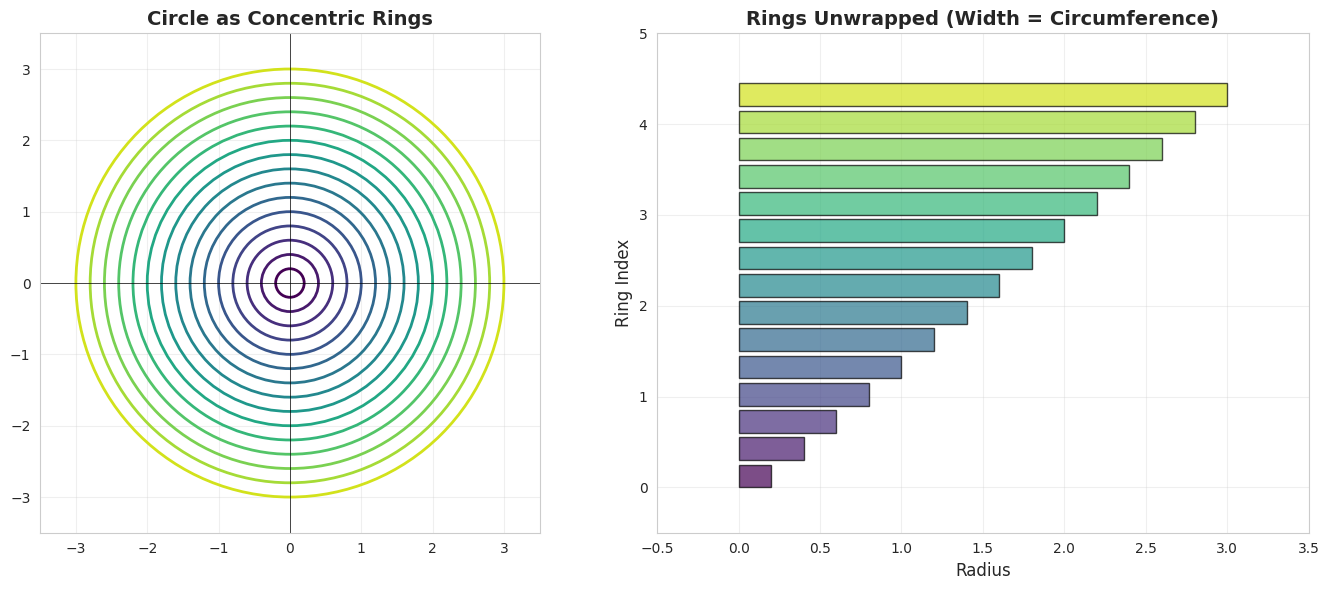

Circle Area via Rings:

Each ring: Area ≈ Circumference × Thickness
          ≈ 2πr × dr

Total area = ∫ 2πr dr from 0 to R
           = πR²


In [ ]:
from matplotlib.patches import Rectangle

def visualize_circle_rings():
    """Show how a circle is built from concentric rings."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Left: Rings
    ax1 = axes[0]
    R = 3
    n_rings = 15
    
    cmap = plt.get_cmap('viridis')
    for i in range(n_rings):
        r = R * (i + 1) / n_rings
        circle = plt.Circle((0, 0), r, fill=False, 
                          color=cmap(i/n_rings), linewidth=2)
        ax1.add_patch(circle)
    
    ax1.set_xlim(-R-0.5, R+0.5)
    ax1.set_ylim(-R-0.5, R+0.5)
    ax1.set_aspect('equal')
    ax1.grid(True, alpha=0.3)
    ax1.set_title('Circle as Concentric Rings', fontsize=14, fontweight='bold')
    ax1.axhline(0, color='k', linewidth=0.5)
    ax1.axvline(0, color='k', linewidth=0.5)
    
    # Right: Unwrapped rings
    ax2 = axes[1]
    radii = np.linspace(0.2, R, n_rings)
    for i, r in enumerate(radii):
        circumference = 2 * np.pi * r
        color = cmap(i/n_rings)
        
        # Draw as rectangle (unwrapped ring)
        # Draw as rectangle (unwrapped ring)
        rect_width = circumference / (2*np.pi) 
        rect = Rectangle((0, i*0.3), rect_width, 0.25,
                        facecolor=color, edgecolor='black', alpha=0.7)
        ax2.add_patch(rect)
    
    ax2.set_xlim(-0.5, R+0.5)
    ax2.set_ylim(-0.5, n_rings*0.3 + 0.5)
    ax2.set_xlabel('Radius', fontsize=12)
    ax2.set_ylabel('Ring Index', fontsize=12)
    ax2.set_title('Rings Unwrapped (Width = Circumference)', 
                 fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("Circle Area via Rings:\n")
    print("Each ring: Area ≈ Circumference × Thickness")
    print("          ≈ 2πr × dr")
    print("\nTotal area = ∫ 2πr dr from 0 to R")
    print("           = πR²")

visualize_circle_rings()

## 2. The Derivative: Instantaneous Rate of Change

Imagine a car moving. Its position changes over time.

**Average velocity** over an interval [t₁, t₂]:
$$
v_{avg} = \frac{\Delta s}{\Delta t} = \frac{s(t_2) - s(t_1)}{t_2 - t_1}
$$

**Instantaneous velocity** at time t:  
Make Δt infinitesimally small!

$$
v(t) = \lim_{\Delta t \to 0} \frac{s(t + \Delta t) - s(t)}{\Delta t} = \frac{ds}{dt}
$$

This is the **derivative**!

In [ ]:
def visualize_instantaneous_velocity():
    """Show how instantaneous velocity emerges from average velocity."""
    
    # Position function: s(t) = t²
    def s(t):
        return t**2
    
    t = np.linspace(0, 5, 100)
    position = s(t)
    
    # Focus point
    t0 = 2.5
    s0 = s(t0)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Left: Position vs Time
    ax1 = axes[0]
    ax1.plot(t, position, 'b-', linewidth=3, label='Position s(t) = t²')
    ax1.plot(t0, s0, 'ro', markersize=10, label=f'Point at t={t0}')
    
    # Show secant lines with decreasing intervals
    colors = ['red', 'orange', 'yellow', 'lightgreen']
    dt_values = [2.0, 1.0, 0.5, 0.1]
    
    for i, dt in enumerate(dt_values):
        t1 = t0 + dt
        s1 = s(t1)
        slope = (s1 - s0) / dt
        
        # Secant line
        t_line = np.array([t0, t1])
        s_line = s0 + slope * (t_line - t0)
        
        ax1.plot(t_line, s_line, '--', color=colors[i], linewidth=2,
                alpha=0.7, label=f'Δt={dt:.1f}, slope={slope:.2f}')
    
    # Tangent line (true derivative at t0)
    true_slope = 2 * t0  # derivative of t² is 2t
    t_tangent = np.linspace(t0-1, t0+1, 50)
    s_tangent = s0 + true_slope * (t_tangent - t0)
    ax1.plot(t_tangent, s_tangent, 'g-', linewidth=3, 
            label=f'Tangent (v={true_slope:.1f})')
    
    ax1.set_xlabel('Time t', fontsize=12)
    ax1.set_ylabel('Position s', fontsize=12)
    ax1.set_title('Instantaneous Velocity as Δt → 0', 
                 fontsize=14, fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Right: Slope vs Δt
    ax2 = axes[1]
    dt_range = np.linspace(0.01, 3, 100)
    slopes = [(s(t0 + dt) - s0) / dt for dt in dt_range]
    
    ax2.plot(dt_range, slopes, 'b-', linewidth=2, label='Average velocity')
    ax2.axhline(true_slope, color='g', linestyle='--', linewidth=2,
               label=f'True instantaneous velocity = {true_slope:.1f}')
    ax2.set_xlabel('Δt', fontsize=12)
    ax2.set_ylabel('Slope (velocity)', fontsize=12)
    ax2.set_title('Convergence to Instantaneous Velocity',
                 fontsize=14, fontweight='bold')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"At t = {t0}:")
    print(f"Position s(t) = t² = {s0:.2f}")
    print(f"Instantaneous velocity v = ds/dt = 2t = {true_slope:.2f}")

visualize_instantaneous_velocity()

## Summary

### The Essence of Calculus

**Derivatives**: Instantaneous rates of change
- Limit of average rates as interval shrinks
- Tangent line slope
- Velocity, acceleration, marginal cost...

**Integrals**: Accumulation of infinitesimal pieces
- Area under curves
- Total distance, work, probability...

**The Connection**: They're inverses!

### Next Steps

In the following chapters, we'll:
1. Define derivatives precisely
2. Learn computation techniques
3. Understand integration
4. Discover the Fundamental Theorem

Welcome to the beautiful world of calculus! 🎓